# <center> Solución de ecuaciones no lineales

$x tan x = 0$<br>
Método:<br>
- Eficiente
- Converger rápido
- Raíces múltiples

**Los métodos que veremos son:** <br>
- Método de búsqueda incremental
- Método de bisección
- Método Newton Rhapson
- Secante
- Ridders

## Búsqueda incremental

Haremos una partición del intervalo con pasos h

In [6]:
import matplotlib.pyplot as plt
import numpy as np

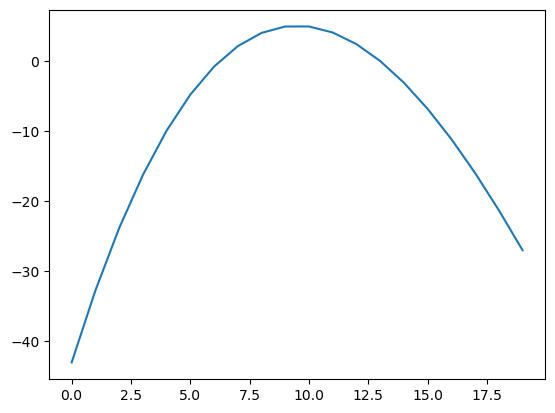

In [30]:
f = x**3 - 10*x**2 + 5 
fig = plt.figure(figsize=(6,6))


In [32]:
# Pon tu función búsqueda incremental, debe recibir una función a evaluar y un intervalo
def busqueda_incremental(f,a,b,h=1e-6):

    x0 = a
    x1 = a+h
    n = 0
    while f(x0)*f(x1) > 0:
        if x0>b: return 'Función sin raíces'
        x0 = x1
        x1 = x0+h
        n += 1
    return x1,n

In [34]:
f = lambda x: x**3-10*x**2+5
print(busqueda_incremental(f,10.5,11,1e-3))

#def f(x):
#    y = x**3-10x**2+5
#    return y
# es equivalente a nombre_función = lambda variables: x**3-10x**2+5

Función sin raíces


In [42]:
import pandas as pd
lista_incremental = []
idx = []
valor_real=0.7346035077893032 #valor obtenido con tolerancia de 10-17
for i in range(1,6):
    tol = 10**(-i)
    idx.append(tol)
    raiz=busqueda_incremental(f,0,1,tol) #cada renglon de la tabla
    error=(abs(valor_real-raiz[0])/valor_real)*100
    lista_incremental.append([raiz[0],raiz[1],error])
cols = ['Raíz','Pasos','error %']
pd.DataFrame(lista_incremental, index = idx, columns=cols)

,Raíz,Pasos,error %
0.10000,0.80000,7,8.902284
0.01000,0.74000,73,0.734613
0.00100,0.73500,734,0.053974
0.00010,0.73470,7346,0.013135
0.00001,0.73461,73460,0.000884


## Bisección
Tengo una función, tomo un intervalo donde yo creo que está la raíz de la función [a,b], parto mi intervalo a la mitad, tomo c = $\frac{x0+x1}{2}$ media aritmética, pregunto si hubo cambio de signo de [a,c] y [c,b], si hay cambio de signo en alguno de los dos repetimos el proceso hasta ensandwichar el punto <br>
- x0 = a, x1 = b <br>
- x2
- f(x0)f(x2)<0 ; x1=x2
- f(x2)f(x1)<0; x0 = x2
<br><br>
- |x_n - x_{n-1}|<|0|

In [53]:
def biseccion(f,a,b):
    x2 = (x1 + x0 )/2
    x0 = a
    x1 = b
    n = 0
    if f(x0)*f(x2) < 0 : 
        x1=x2
    elif f(x2)*f(x1) < 0 : 
        x0=x2
    else: print('No hay raices')

In [54]:
print(biseccion(f,10.5,11))

UnboundLocalError: cannot access local variable 'x1' where it is not associated with a value

In [55]:
#Biseccion
def biseccion(f,a,b,epsilon=1e-6):
    x0, x1, n=a,b,0
    while abs(x0-x1)>epsilon:
        x2=(x0+x1)/2
        n+=1
        if f(x0)*f(x2)<0:#intervalo izq
            x1=x2
        elif f(x1)*f(x2)<0: #int
            x0=x2
    return x1,n

In [56]:
print(biseccion(f,0,0.8,1e-10))

(0.7346035078167915, 33)


In [57]:
l_biseccion = []
idx = []
valor_real=0.7346035077893032 #valor obtenido con tolerancia de 10-17
for i in range(1,6):
    tol = 10**(-i)
    idx.append(tol)
    raiz=biseccion(f,0,1,tol) #cada renglon de la tabla
    error=(abs(valor_real-raiz[0])/valor_real)*100
    lista_incremental.append([raiz[0],raiz[1],error])
cols = ['Raíz','Pasos','error %']
pd.DataFrame(l_biseccion, index = idx, columns=cols)

,Raíz,Pasos,error %
0.10000,NaN,NaN,NaN
0.01000,NaN,NaN,NaN
0.00100,NaN,NaN,NaN
0.00010,NaN,NaN,NaN
0.00001,NaN,NaN,NaN


## Newton - Rhapson
Usamos la recta tangente para ir definiendo la derivada, iniciamos con un paso inicial y la aproximación será la tangente a ese punto, el punto donde la tangente corta al eje x es la primer aproximación.<br><br>
pediremos la función, la derivada de la función, el paso inicial y con esto calcularemos 
- f, f' , x0
- x1 si f(x1)=0 <br>

Los contras son que la función debe ser contínua y derivable, además bien comportada<br>
Pros: convergencia cuadrática, fácil de entender y programar

Para subir:
- Encontrar x1 con la serie de taylor o la ecuación de la recta y ponerlo en un markdown
- Escribir su propia función de NR
- Dataframe con la prueba de convergencia
- Entregar el notebook

aproximo x1 con Serie de taylor centrada en x0, me quedo con la parte lineal 

Nuestra función es:
$$x^3-10x^2+5$$
La serie de Taylor para cuálquier función es:
$$f(x) = \sum_{n=0}^{\infty}\frac{f^{(n)}(a)}{n!}(x-a)^n$$
Para nuestra función, la pendiente es $$3x^2-20x$$
Debemos evaluar en un punto inicial $x0$ y proyectar al eje x para encontrar el valor donde se haga cero, esto será nuestro $x1$

$$f(x_1) = x_0 + (3(x_1)^2 - 20x_1)(x_1 - x_0)$$